In [9]:

import pandas as pd

PATH = "../data/raw/churn-prediction.csv"

df = pd.read_csv(PATH)

df.head()



,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


### Em nosso dataset vemos 2 colunas categoricas, e 10 numericas.
### As colunas credit_card, active_member, products_number apesar de numericas sao categoricas "disfarcadas" 
### Nosso target sera a coluna 11 (Churn) onde:
- 1 -> cliente deixou o banco
- 0 -> cliente nao deixou o banco

In [15]:
df["churn"].value_counts()

churn
0    7963
1    2037
Name: count, dtype: int64

In [17]:
churn_percentage = df["churn"].value_counts(normalize=True) * 100
churn_percentage

churn
0    79.63
1    20.37
Name: proportion, dtype: float64

### Aqui podemos ver que nosso dataset e levemente desbalanceado, apenas 20.37% dos casos sao churn.
### Por ser desbalanceado, metricas como accuracy podem nao ser confiaveis, sendo metricas como recall, precision e F1-score mais apropriadas.


## Questoes a investigar
* Quais fatores levam ao churn?
* Clientes inativos churnam mais?
* Clientes com menos produtos deixam o banco mais frequentemente?


Text(0.5, 0, 'Churn')

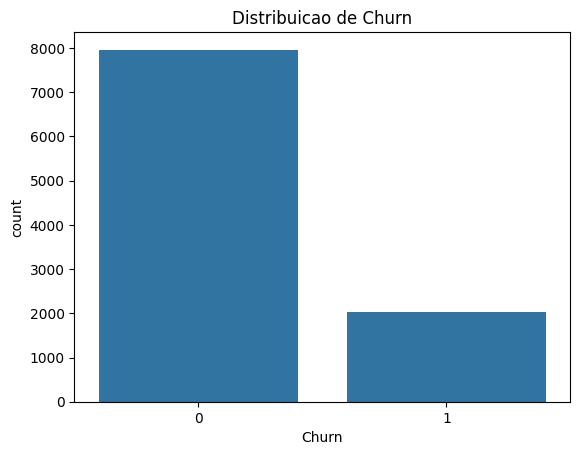

In [19]:
from matplotlib import pyplot as plt
import seaborn as sns

sns.countplot(x="churn", data=df)
plt.title("Distribuicao de Churn")
plt.xlabel("Churn")    

Text(0, 0.5, 'Contagem')

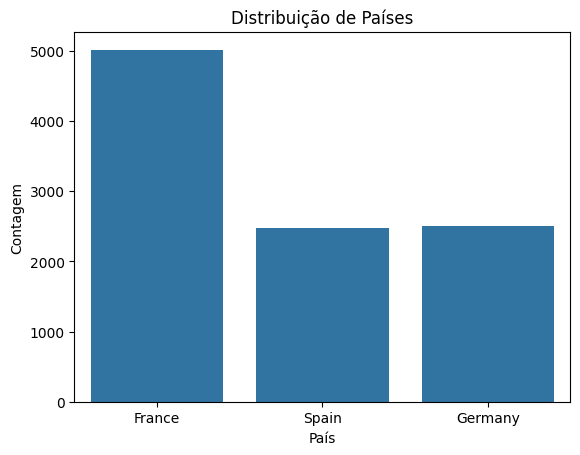

In [31]:
sns.countplot(x="country", data=df)
plt.title("Distribuição de Países")
plt.xlabel("País")
plt.ylabel("Contagem")  

### Aqui vemos que a Franca e o pais com maior numero de clientes

Text(0.5, 1.0, 'Taxa de Churn por País')

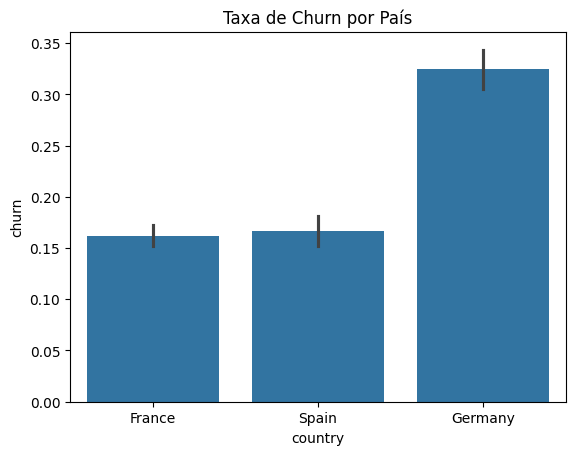

In [33]:
sns.barplot(x="country", y="churn", data=df)
plt.title("Taxa de Churn por País") 

### Apesar da Franca ser o pais com maior numero de clientes, a Alemanha e de onde vem o maior peso de churn


Text(0, 0.5, 'Contagem')

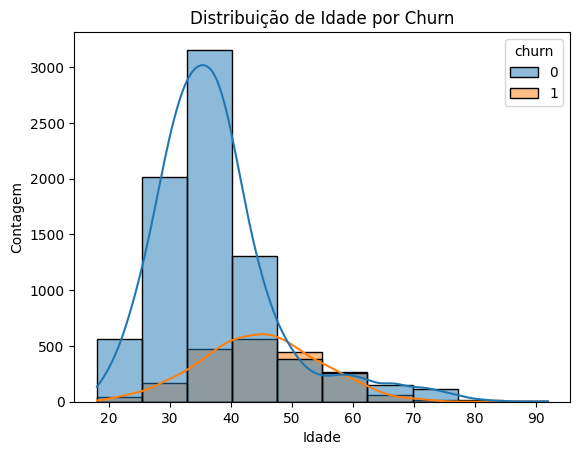

In [41]:
sns.histplot(data=df, x="age", hue="churn", bins=10, kde=True) 
plt.title("Distribuição de Idade por Churn")
plt.xlabel("Idade")
plt.ylabel("Contagem")      

### Clientes mais velhos churnam mais

Text(0.5, 1.0, 'Tenure por Churn')

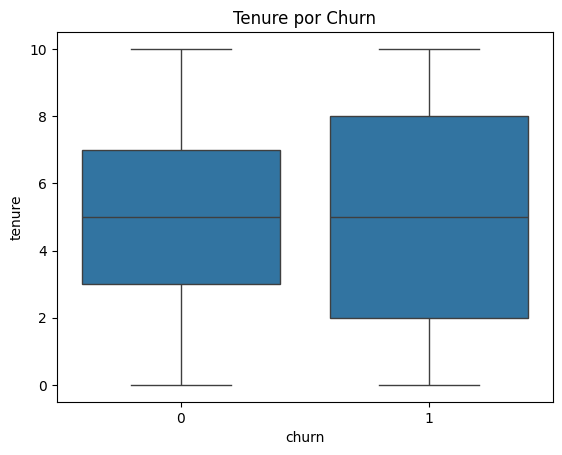

In [37]:
sns.boxplot(x="churn", y="tenure", data=df)
plt.title("Tenure por Churn")

### A distribuição de tenure é bastante semelhante entre clientes que churnaram e os que permaneceram. As medianas são praticamente iguais e há grande sobreposição entre as distribuições, indicando que essa variável isoladamente pode não ser um forte preditor de churn.

Text(0, 0.5, 'Contagem')

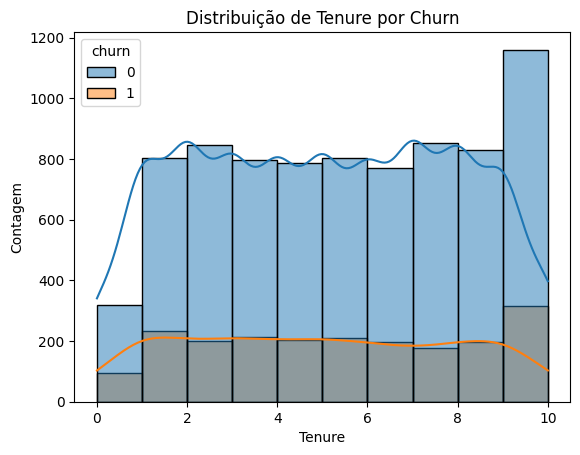

In [39]:
sns.histplot(data=df, x="tenure", hue="churn", bins=10, kde=True)   
plt.title("Distribuição de Tenure por Churn")
plt.xlabel("Tenure")
plt.ylabel("Contagem")  

Text(0.5, 0, 'Balance')

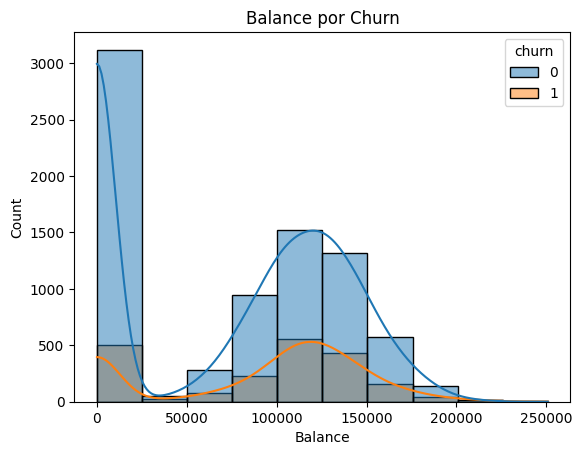

In [45]:
sns.histplot(data=df, x="balance", hue="churn", bins=10, kde=True)
plt.title("Balance por Churn")
plt.xlabel("Balance")       

### Clientes que possuem saldo proximo a zero tendem a sair mais que os que os com saldo maiores. Com outro pico na casa de 125000 de saldo